<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
import numpy as np

In [13]:
df=pd.read_csv('/content/drive/MyDrive/FitPulse Health Anomaly Detection from Fitness Devices/FitPulse_final_dataset.csv')

In [14]:
df

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7904,P8668,62.973343,8.0,NaN,2025-01-19 00:35:00,88,163,M,26,2965,7.9,9876,87
7905,P8669,86.473075,43.0,NaN,2025-01-19 17:10:00,77,163,F,25,2127,7.4,9526,97
7906,P8670,66.679417,10.0,NaN,2025-01-03 23:40:00,68,175,F,53,1830,7.9,9543,67
7907,P8671,61.162288,13.0,NaN,2025-01-26 05:50:00,73,178,M,24,2554,7.3,8869,89


In [15]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df = df.sort_values(['Patient_ID', 'time_stamp'])

In [16]:
from tsfresh import extract_features

# Fill NaN values in 'sleep_tracking' column with 0
df['sleep_tracking'] = df['sleep_tracking'].fillna(0)

# Create a copy of df and drop non-time-series columns like 'gender'
# before passing to tsfresh to avoid errors on non-numeric columns.
df_tsfresh_input = df.drop(columns=['gender']).copy()

# Limit to first 300 rows for quicker feature extraction during testing
df_tsfresh_input = df_tsfresh_input.head(100)

tsfresh_df = extract_features(
    df_tsfresh_input,
    column_id='Patient_ID',
    column_sort='time_stamp',
    column_kind=None,
    column_value=None,
    default_fc_parameters=None
)

print(f"Shape of tsfresh_df: {tsfresh_df.shape}") # Added to inspect the shape

Feature Extraction: 100%|██████████| 1000/1000 [01:24<00:00, 11.79it/s]


Shape of tsfresh_df: (100, 7830)


In [17]:
import pandas as pd
import numpy as np

In [18]:
df=pd.read_csv('/content/drive/MyDrive/FitPulse Health Anomaly Detection from Fitness Devices/FitPulse_final_dataset.csv')

In [19]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df = df.sort_values(['Patient_ID', 'time_stamp'])

In [20]:
from sklearn.preprocessing import StandardScaler

# Select relevant numerical columns from the original df for clustering
df_features_for_clustering = df[['heart_rate', 'step_count', 'sleep_tracking', 'Weight', 'Height', 'age', 'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate']].copy()

# Handle potential NaN values in these features by filling with 0 or mean/median
# For simplicity, let's fill with 0, but a more robust strategy might be needed based on data distribution.
df_features_for_clustering = df_features_for_clustering.fillna(0)

X = df_features_for_clustering.values
X_scaled = StandardScaler().fit_transform(X)

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
# Apply KMeans directly to the scaled numerical features from the original df
df['cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2.0, min_samples=10)
# Apply DBSCAN directly to the scaled numerical features from the original df
df['dbscan_cluster'] = db.fit_predict(X_scaled)

In [24]:
tsfresh_df = tsfresh_df.fillna(0)

In [64]:
from prophet import Prophet

def run_prophet(df, value_col):
    temp = df[['time_stamp', value_col]].rename(
        columns={'time_stamp': 'ds', value_col: 'y'}
    )

    # Drop rows where 'y' (value_col) is NaN, as Prophet cannot handle them.
    temp.dropna(subset=['y'], inplace=True)

    # Prophet requires at least 2 data points for fitting.
    if len(temp) < 2:
        print(f"Patient {df['Patient_ID'].iloc[0]} has less than 2 non-NaN data points for '{value_col}'. Skipping Prophet modeling.")
        return None

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model.fit(temp)
    forecast = model.predict(temp)

    return forecast

In [27]:
patient_counts = df['Patient_ID'].value_counts()
eligible_patient_id = None
# Prophet generally requires a good amount of data to detect seasonality and trends.
# A common recommendation is at least several weeks or months of data.
# We'll set a higher threshold for `eligible_patient_id` to ensure more robust modeling.
# For example, let's aim for at least 30 observations.
for patient_id, count in patient_counts.items():
    if count >= 30: # Changed from 2 to 30 to ensure sufficient data for Prophet
        eligible_patient_id = patient_id
        break

if eligible_patient_id:
    print(f"Using Patient_ID: {eligible_patient_id} for Prophet modeling.")
    prophet_steps = run_prophet(df[df['Patient_ID'] == eligible_patient_id], 'daily_steps')
    prophet_hr = run_prophet(df[df['Patient_ID'] == eligible_patient_id], 'resting_heart_rate')
else:
    print("No patient has at least 30 data points for time series analysis using Prophet. Prophet modeling for individual patients cannot proceed with this dataset.")
    prophet_steps = None
    prophet_hr = None

No patient has at least 30 data points for time series analysis using Prophet. Prophet modeling for individual patients cannot proceed with this dataset.


In [28]:
from sklearn.preprocessing import StandardScaler

# Select relevant numerical columns from the original df for clustering
df_features_for_clustering = df[['heart_rate', 'step_count', 'sleep_tracking', 'Weight', 'Height', 'age', 'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate']].copy()

# Handle potential NaN values in these features by filling with 0 or mean/median
# For simplicity, let's fill with 0, but a more robust strategy might be needed based on data distribution.
df_features_for_clustering = df_features_for_clustering.fillna(0)

X = df_features_for_clustering.values
X_scaled = StandardScaler().fit_transform(X)

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
# Apply KMeans directly to the scaled numerical features from the original df
df['cluster'] = kmeans.fit_predict(X_scaled)

In [30]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2.0, min_samples=10)
# Apply DBSCAN directly to the scaled numerical features from the original df
df['dbscan_cluster'] = db.fit_predict(X_scaled)

In [31]:
from prophet import Prophet

def prophet_model(df, col):
    temp = df[['timestamp', col]].rename(
        columns={'timestamp': 'ds', col: 'y'}
    )

    model = Prophet(daily_seasonality=True)
    model.fit(temp)
    return model.predict(temp)


In [34]:
user_id = 'P0001' # Changed to a string as Patient_ID seems to be string type
user_df = df[df['Patient_ID'] == user_id].copy()
user_df = user_df.sort_values('time_stamp')

In [66]:
from prophet import Prophet

def prophet_model(df, value_col):
    temp = df[['time_stamp', value_col]].rename(
        columns={'time_stamp': 'ds', value_col: 'y'}
    )

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(temp)
    forecast = model.predict(temp)

    # Merge actual values back
    forecast = forecast.merge(
        temp[['ds', 'y']],
        on='ds',
        how='left'
    )

    return forecast

In [45]:
# First, ensure 'time_stamp' is in datetime format and set it as index
df_agg_time = df.set_index('time_stamp')

# Resample the data daily and calculate the mean of numerical columns
# We exclude 'Patient_ID' and 'gender' as they are not numerical for mean aggregation
# We also exclude 'sleep_tracking' which is mostly NaN and was filled with 0, so its mean might not be representative in this aggregated context.
# For 'sleep_tracking', if it contained meaningful values, a different aggregation like sum or count might be more appropriate.
aggregated_daily_df = df_agg_time.resample('D')[['heart_rate', 'step_count', 'Weight', 'Height', 'age', 'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate']].mean()

display(aggregated_daily_df.head())

,heart_rate,step_count,Weight,Height,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
time_stamp,,,,,,,,,
2025-01-01,72.291992,28.896552,69.406130,170.260536,41.704981,2238.957854,8.070115,9106.735632,80.107280
2025-01-02,71.668099,25.652985,69.608209,169.664179,42.921642,2259.201493,8.134328,8920.074627,80.231343
2025-01-03,72.638052,24.524345,69.224719,169.423221,40.985019,2239.543071,8.098127,9004.812734,79.880150
2025-01-04,72.234466,25.244094,70.755906,167.783465,44.157480,2270.732283,8.014961,8811.090551,79.393701
2025-01-05,71.974136,23.501946,70.307393,169.941634,43.272374,2266.501946,8.019455,8849.276265,82.027237


In [46]:
from prophet import Prophet

# Prepare the aggregated data for Prophet
prophet_input_df = aggregated_daily_df.reset_index().rename(columns={'time_stamp': 'ds', 'heart_rate': 'y'})

# Drop any rows where 'y' is NaN after aggregation
prophet_input_df.dropna(subset=['y'], inplace=True)

# Check if there's enough data for Prophet
if len(prophet_input_df) < 2:
    print("Not enough daily aggregated data points for Prophet modeling.")
else:
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model.fit(prophet_input_df)
    future = model.make_future_dataframe(periods=7) # Forecast for the next 7 days
    forecast = model.predict(future)

    print("Prophet forecast for aggregated daily heart rate:")
    display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet forecast for aggregated daily heart rate:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,74.128006,70.207276,78.118308
1,2025-01-02,71.598245,67.899367,75.433905
2,2025-01-03,69.736829,65.775947,73.995797
3,2025-01-04,72.293004,68.478994,76.326886
4,2025-01-05,71.857270,68.111723,75.721505


In [47]:
patients_with_more_than_2_data_points = patient_counts[patient_counts > 2]
print(f"Patients with more than 2 data points: {list(patients_with_more_than_2_data_points.index)}")

Patients with more than 2 data points: []


In [48]:
from prophet import Prophet

def prophet_model(df, value_col):
    temp = df[['timestamp', value_col]].rename(
        columns={'timestamp': 'ds', value_col: 'y'}
    )

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(temp)
    forecast = model.predict(temp)

    # Merge actual values back
    forecast = forecast.merge(
        temp[['ds', 'y']],
        on='ds',
        how='left'
    )

    return forecast


In [74]:
from prophet import Prophet
import pandas as pd

df_prophet = df.rename(columns={
    "time_stamp": "ds",
    "resting_heart_rate": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=10, freq="T")
forecast = model.predict(future)

forecast = forecast.merge(
    df_prophet[['ds', 'y']],
    on='ds',
    how='left'
)

forecast['residual'] = forecast['y'] - forecast['yhat']

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


In [72]:
import pandas as pd

# Identify rows where all relevant columns are NaN
# We can check for NaNs in any one column, as we know they all have the same count of NaNs
dates_with_missing_values = aggregated_daily_df[aggregated_daily_df['heart_rate'].isna()].index

print(f"Number of dates with missing values: {len(dates_with_missing_values)}")
print("Dates with missing values (first 10 if many):\n")
for date in dates_with_missing_values.to_list()[:10]:
    print(date.strftime('%Y-%m-%d'))

if len(dates_with_missing_values) > 10:
    print(f"\n... and {len(dates_with_missing_values) - 10} more dates.")

Number of dates with missing values: 297
Dates with missing values (first 10 if many):

2025-02-02
2025-02-03
2025-02-04
2025-02-05
2025-02-06
2025-02-07
2025-02-08
2025-02-09
2025-02-10
2025-02-11

... and 287 more dates.


In [71]:
print("Missing values in aggregated_daily_df:")
display(aggregated_daily_df.isna().sum())

Missing values in aggregated_daily_df:


,0
heart_rate,297
step_count,297
Weight,297
Height,297
age,297
daily_calories,297
daily_sleep_hours,297
daily_steps,297
resting_heart_rate,297


In [59]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Prepare the aggregated data for Prophet using 'daily_steps'
prophet_input_df_steps = aggregated_daily_df.reset_index().rename(columns={'time_stamp': 'ds', 'daily_steps': 'y'})

# Drop any rows where 'y' (daily_steps) is NaN after aggregation
prophet_input_df_steps.dropna(subset=['y'], inplace=True)

# Check if there's enough data for Prophet
if len(prophet_input_df_steps) < 2:
    print("Not enough daily aggregated data points for Prophet modeling for daily_steps.")
else:
    model_steps = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model_steps.fit(prophet_input_df_steps)
    future_steps = model_steps.make_future_dataframe(periods=7) # Forecast for the next 7 days
    forecast_steps = model_steps.predict(future_steps)

    print("Prophet forecast for aggregated daily steps:")
    display(forecast_steps[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet forecast for aggregated daily steps:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,9036.089202,8391.806197,9728.318057
1,2025-01-02,8900.526667,8292.837383,9533.480807
2,2025-01-03,9146.860243,8536.557053,9824.672222
3,2025-01-04,8164.262166,7500.923777,8834.986509
4,2025-01-05,8894.661557,8213.351436,9516.370434


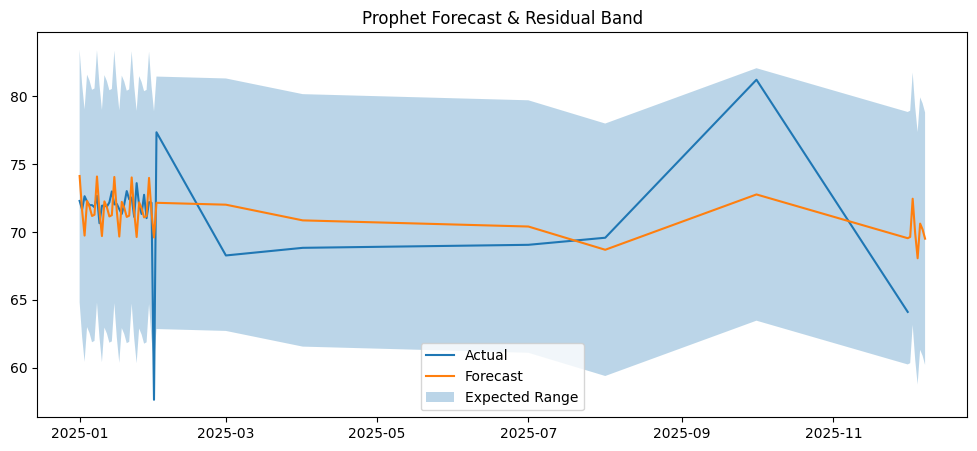

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(forecast_with_actuals['ds'], forecast_with_actuals['y'], label='Actual')
plt.plot(forecast_with_actuals['ds'], forecast_with_actuals['yhat'], label='Forecast')
plt.fill_between(
    forecast_with_actuals['ds'],
    forecast_with_actuals['lower_threshold'],
    forecast_with_actuals['upper_threshold'],
    alpha=0.3,
    label='Expected Range'
)
plt.legend()
plt.title("Prophet Forecast & Residual Band")
plt.show()

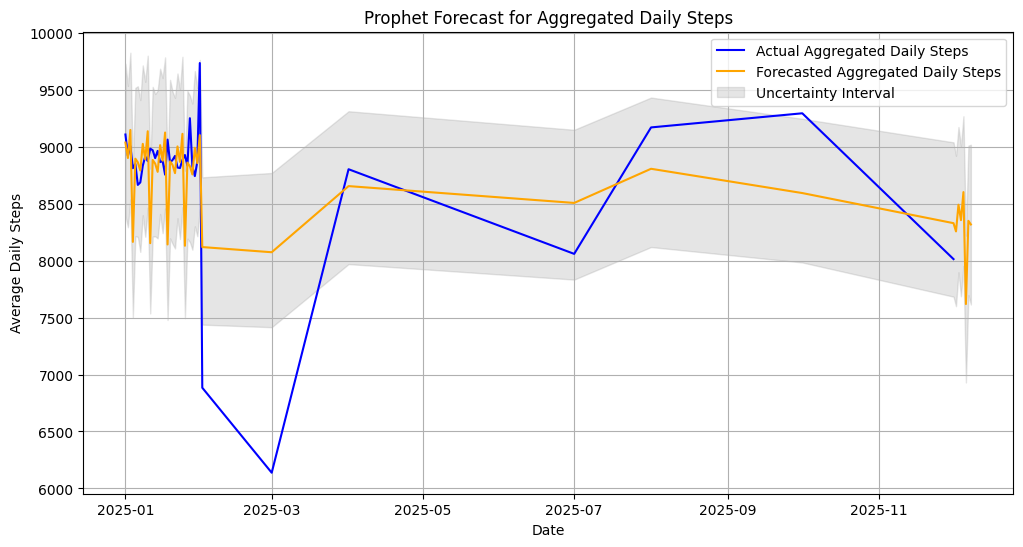

In [60]:
# Plot the Prophet forecast for aggregated daily steps
plt.figure(figsize=(12, 6))
plt.plot(prophet_input_df_steps['ds'], prophet_input_df_steps['y'], label='Actual Aggregated Daily Steps', color='blue')
plt.plot(forecast_steps['ds'], forecast_steps['yhat'], label='Forecasted Aggregated Daily Steps', color='orange')
plt.fill_between(forecast_steps['ds'], forecast_steps['yhat_lower'], forecast_steps['yhat_upper'], color='gray', alpha=0.2, label='Uncertainty Interval')
plt.title('Prophet Forecast for Aggregated Daily Steps')
plt.xlabel('Date')
plt.ylabel('Average Daily Steps')
plt.legend()
plt.grid(True)
plt.show()

### Generating Anomaly Visualization for Aggregated Heart Rate

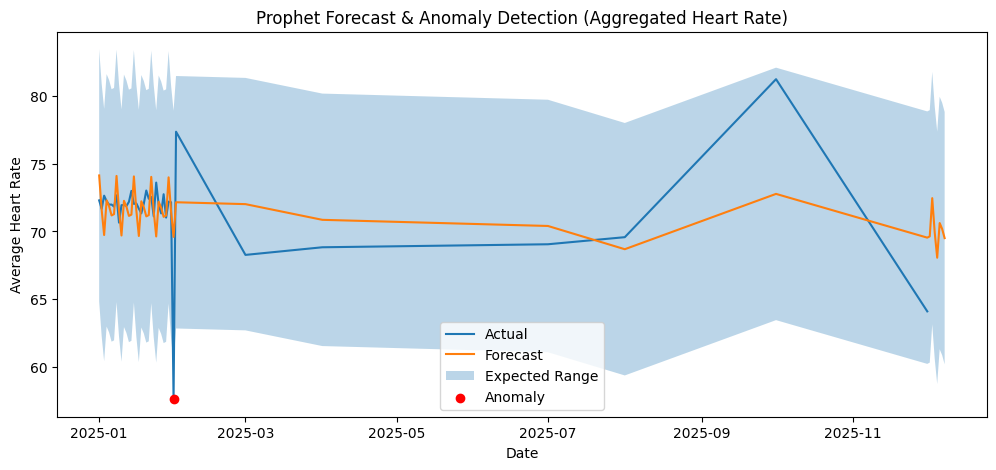

Saved heart_rate_anomalies.png


In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(forecast_with_actuals['ds'], forecast_with_actuals['y'], label='Actual')
plt.plot(forecast_with_actuals['ds'], forecast_with_actuals['yhat'], label='Forecast')
plt.fill_between(
    forecast_with_actuals['ds'],
    forecast_with_actuals['lower_threshold'],
    forecast_with_actuals['upper_threshold'],
    alpha=0.3,
    label='Expected Range'
)
plt.scatter(
    anomalies['ds'],
    anomalies['y'],
    color='red',
    label='Anomaly',
    zorder=5
)
plt.legend()
plt.title("Prophet Forecast & Anomaly Detection (Aggregated Heart Rate)")
plt.xlabel("Date")
plt.ylabel("Average Heart Rate")
plt.savefig('heart_rate_anomalies.png')
plt.show()
print("Saved heart_rate_anomalies.png")

Standard Deviation of Residuals for daily_steps: 518.54


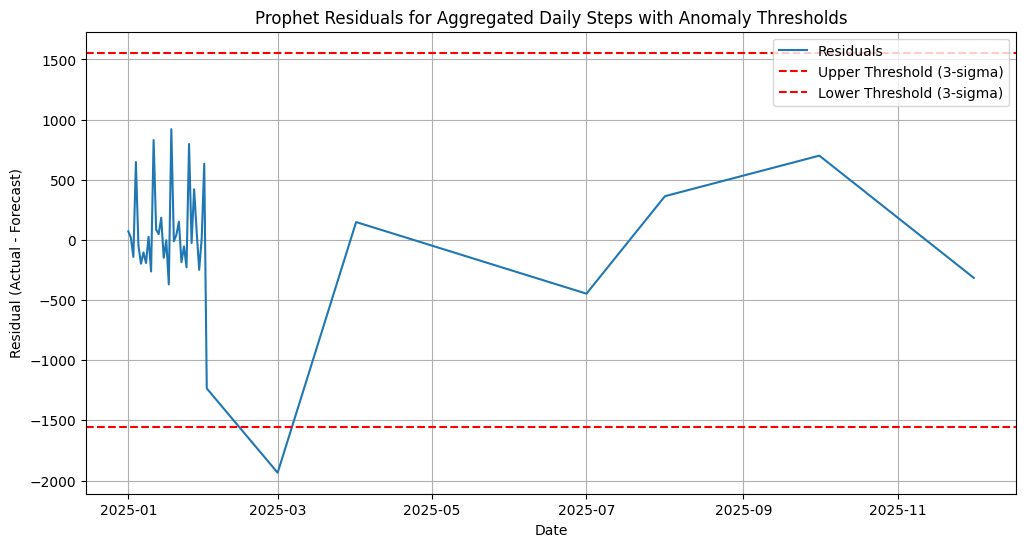


Potential Anomalies Detected for daily_steps:


,ds,y,yhat,residual,upper_threshold,lower_threshold
32,2025-03-01,6138.0,8073.338785,-1935.338785,9628.958831,6517.718738


In [61]:
# Calculate residuals and identify anomalies for daily_steps
forecast_with_actuals_steps = forecast_steps.merge(
    prophet_input_df_steps[['ds', 'y']],
    on='ds',
    how='left'
)

forecast_with_actuals_steps['residual'] = forecast_with_actuals_steps['y'] - forecast_with_actuals_steps['yhat']
residual_std_steps = forecast_with_actuals_steps['residual'].std()

# Define anomaly thresholds (e.g., 3 standard deviations from the mean residual)
forecast_with_actuals_steps['upper_threshold'] = forecast_with_actuals_steps['yhat'] + 3 * residual_std_steps
forecast_with_actuals_steps['lower_threshold'] = forecast_with_actuals_steps['yhat'] - 3 * residual_std_steps

print(f"Standard Deviation of Residuals for daily_steps: {residual_std_steps:.2f}")

# Plot the residuals for daily_steps
plt.figure(figsize=(12, 6))
plt.plot(forecast_with_actuals_steps['ds'], forecast_with_actuals_steps['residual'], label='Residuals')
plt.axhline(y=3 * residual_std_steps, color='r', linestyle='--', label='Upper Threshold (3-sigma)')
plt.axhline(y=-3 * residual_std_steps, color='r', linestyle='--', label='Lower Threshold (3-sigma)')
plt.title('Prophet Residuals for Aggregated Daily Steps with Anomaly Thresholds')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Forecast)')
plt.legend()
plt.grid(True)
plt.show()

# Identify potential anomalies for daily_steps
anomalies_steps = forecast_with_actuals_steps[
    (forecast_with_actuals_steps['residual'] > 3 * residual_std_steps) |
    (forecast_with_actuals_steps['residual'] < -3 * residual_std_steps)
]

if not anomalies_steps.empty:
    print("\nPotential Anomalies Detected for daily_steps:")
    display(anomalies_steps[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
else:
    print("\nNo significant anomalies detected for daily_steps based on 3-sigma threshold.")

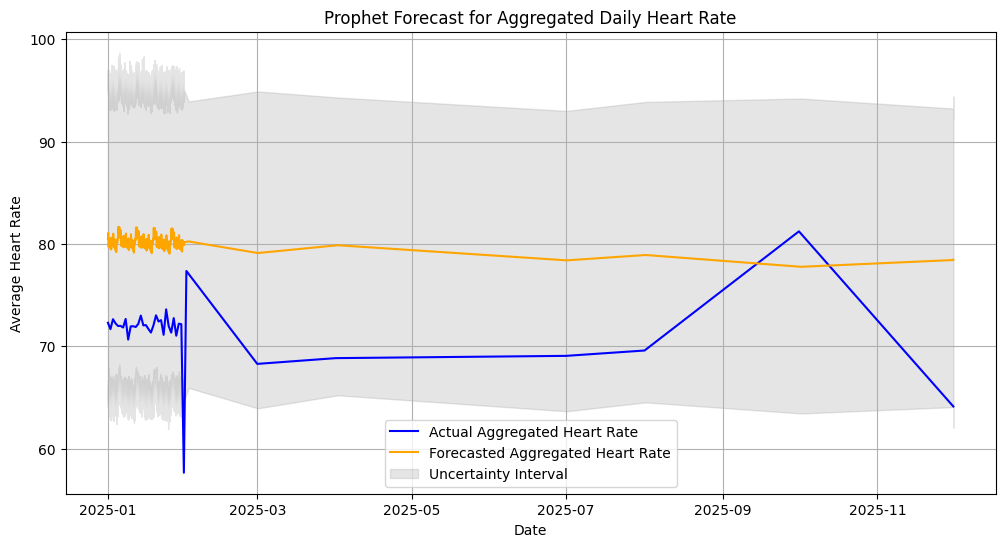

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(prophet_input_df['ds'], prophet_input_df['y'], label='Actual Aggregated Heart Rate', color='blue')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecasted Aggregated Heart Rate', color='orange')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.2, label='Uncertainty Interval')
plt.title('Prophet Forecast for Aggregated Daily Heart Rate')
plt.xlabel('Date')
plt.ylabel('Average Heart Rate')
plt.legend()
plt.grid(True)
plt.show()

Standard Deviation of Residuals: 3.10


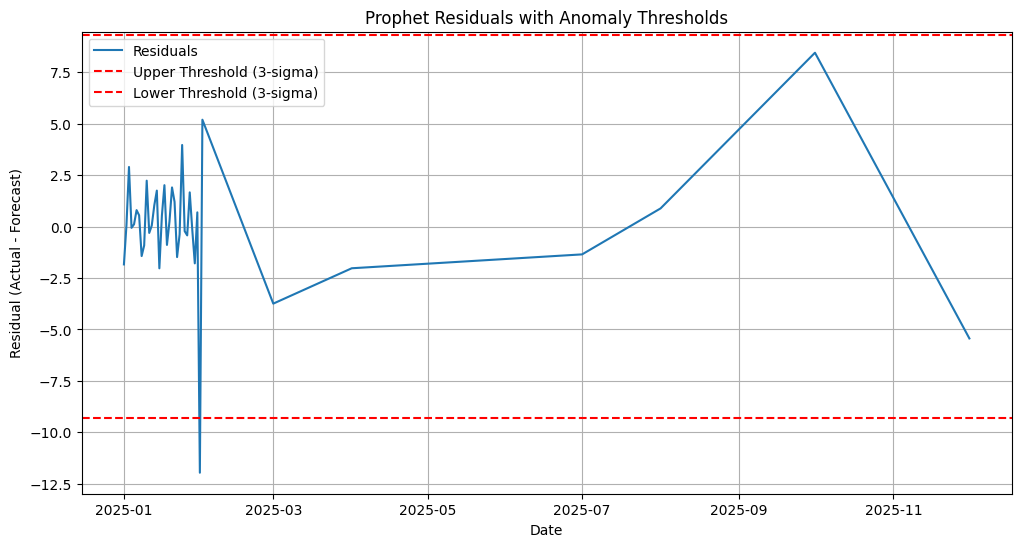


Potential Anomalies Detected:


,ds,y,yhat,residual,upper_threshold,lower_threshold
30,2025-01-31,57.634601,69.597484,-11.962883,78.902323,60.292646


In [51]:
# Merge actual values back into the forecast DataFrame to calculate residuals
forecast_with_actuals = forecast.merge(
    prophet_input_df[['ds', 'y']],
    on='ds',
    how='left'
)

forecast_with_actuals['residual'] = forecast_with_actuals['y'] - forecast_with_actuals['yhat']
residual_std = forecast_with_actuals['residual'].std()

# Define anomaly thresholds (e.g., 3 standard deviations from the mean residual)
forecast_with_actuals['upper_threshold'] = forecast_with_actuals['yhat'] + 3 * residual_std
forecast_with_actuals['lower_threshold'] = forecast_with_actuals['yhat'] - 3 * residual_std

print(f"Standard Deviation of Residuals: {residual_std:.2f}")

# Plot the residuals
plt.figure(figsize=(12, 6))
plt.plot(forecast_with_actuals['ds'], forecast_with_actuals['residual'], label='Residuals')
plt.axhline(y=3 * residual_std, color='r', linestyle='--', label='Upper Threshold (3-sigma)')
plt.axhline(y=-3 * residual_std, color='r', linestyle='--', label='Lower Threshold (3-sigma)')
plt.title('Prophet Residuals with Anomaly Thresholds')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Forecast)')
plt.legend()
plt.grid(True)
plt.show()

# Identify potential anomalies
anomalies = forecast_with_actuals[
    (forecast_with_actuals['residual'] > 3 * residual_std) |
    (forecast_with_actuals['residual'] < -3 * residual_std)
]

if not anomalies.empty:
    print("\nPotential Anomalies Detected:")
    display(anomalies[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
else:
    print("\nNo significant anomalies detected based on 3-sigma threshold.")

In [78]:
residual_std = forecast['residual'].std()

forecast['upper_threshold'] = forecast['yhat'] + 3 * residual_std
forecast['lower_threshold'] = forecast['yhat'] - 3 * residual_std


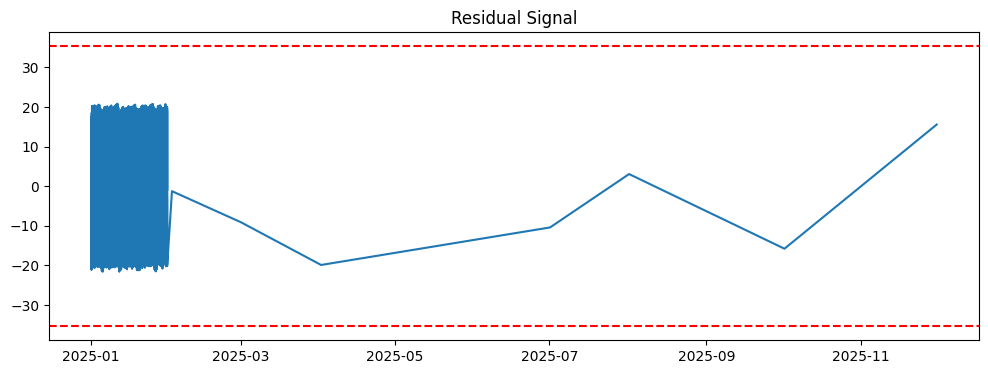

In [79]:
plt.figure(figsize=(12,4))
plt.plot(forecast['ds'], forecast['residual'])
plt.axhline(3*residual_std, color='red', linestyle='--')
plt.axhline(-3*residual_std, color='red', linestyle='--')
plt.title("Residual Signal")
plt.show()


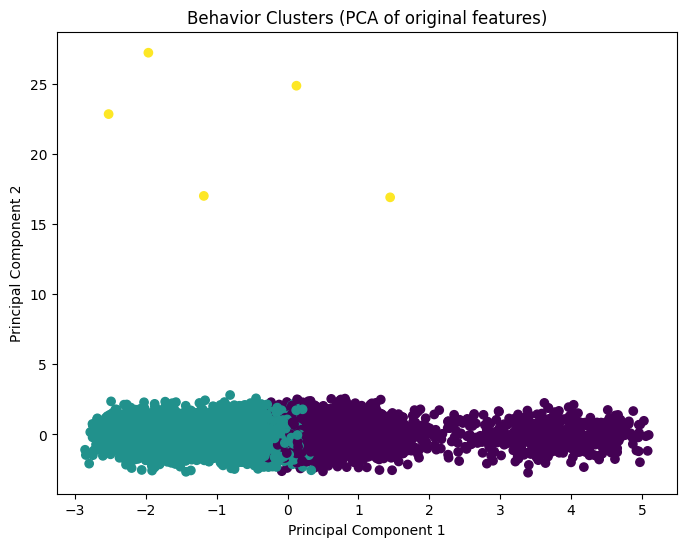

In [80]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
# Apply PCA directly to the scaled numerical features from the original df
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("Behavior Clusters (PCA of original features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


No significant anomalies detected for sleep_tracking based on 3-sigma threshold.


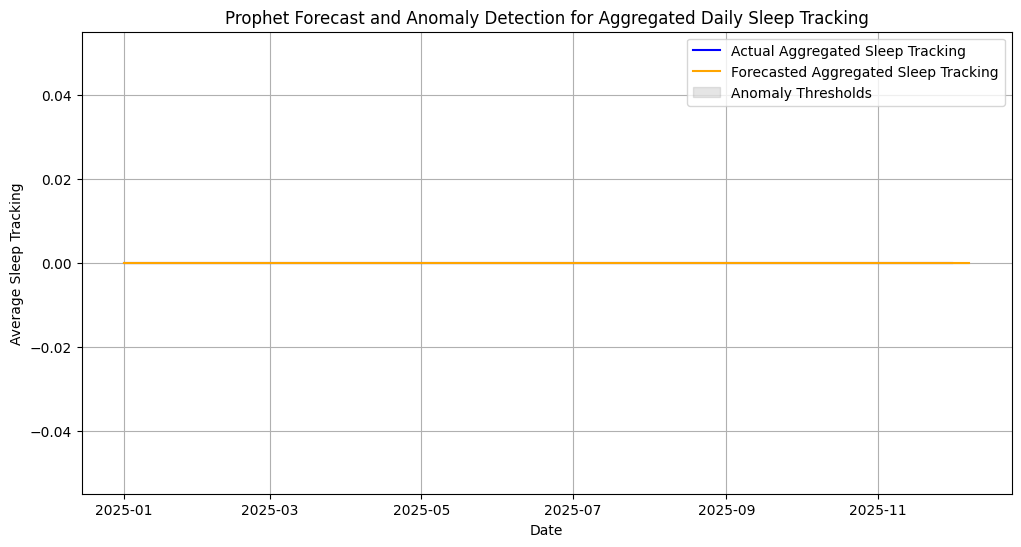

Saved sleep_anomalies.png


In [85]:
import matplotlib.pyplot as plt

if forecast_sleep is not None:
    # Identify potential anomalies for daily_sleep_tracking
    anomalies_sleep = forecast_with_actuals_sleep[
        (forecast_with_actuals_sleep['residual'] > 3 * residual_std_sleep) |
        (forecast_with_actuals_sleep['residual'] < -3 * residual_std_sleep)
    ]

    plt.figure(figsize=(12, 6))
    plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['y'], label='Actual Aggregated Sleep Tracking', color='blue')
    plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['yhat'], label='Forecasted Aggregated Sleep Tracking', color='orange')
    plt.fill_between(
        forecast_with_actuals_sleep['ds'],
        forecast_with_actuals_sleep['lower_threshold'],
        forecast_with_actuals_sleep['upper_threshold'],
        color='gray', alpha=0.2, label='Anomaly Thresholds'
    )

    if not anomalies_sleep.empty:
        plt.scatter(
            anomalies_sleep['ds'],
            anomalies_sleep['y'],
            color='red', marker='o', s=50, zorder=5, label='Anomalies'
        )
        print("\nPotential Anomalies Detected for sleep_tracking:")
        display(anomalies_sleep[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
    else:
        print("\nNo significant anomalies detected for sleep_tracking based on 3-sigma threshold.")

    plt.title('Prophet Forecast and Anomaly Detection for Aggregated Daily Sleep Tracking')
    plt.xlabel('Date')
    plt.ylabel('Average Sleep Tracking')
    plt.legend()
    plt.grid(True)
    plt.savefig('sleep_anomalies.png')
    plt.show()
    print("Saved sleep_anomalies.png")
else:
    print("Skipping sleep_tracking anomaly visualization as no Prophet model was fitted.")